In [1]:
import pandas as pd
import numpy as np


df_A = pd.read_csv('../data/data_A.csv')
X_train_A = df_A['x'].values
y_train_A = df_A['y'].values

df_B_train = pd.read_csv('../data/data_B_train.csv')
df_B_val = pd.read_csv('../data/data_B_val.csv')

X_train_B = df_B_train['x'].values
y_train_B = df_B_train['y'].values

X_val_B = df_B_val['x'].values
y_val_B = df_B_val['y'].values

print(f"Data A loaded: {len(X_train_A)} training samples.")
print(
    f"Data B loaded: {len(X_train_B)} training samples, {len(X_val_B)} validation samples.")

Data A loaded: 200 training samples.
Data B loaded: 20 training samples, 20 validation samples.


In [ ]:
def get_poly_features(x, degree):
    X_mat = np.ones((len(x), 1))
    for d in range(1, degree + 1):
        X_mat = np.hstack((X_mat, (x**d).reshape(-1, 1)))
    return X_mat

def solve_normal_equation(X, y):
    theta = np.linalg.inv(X.T @ X) @ X.T @ y
    return theta

/home/wren/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


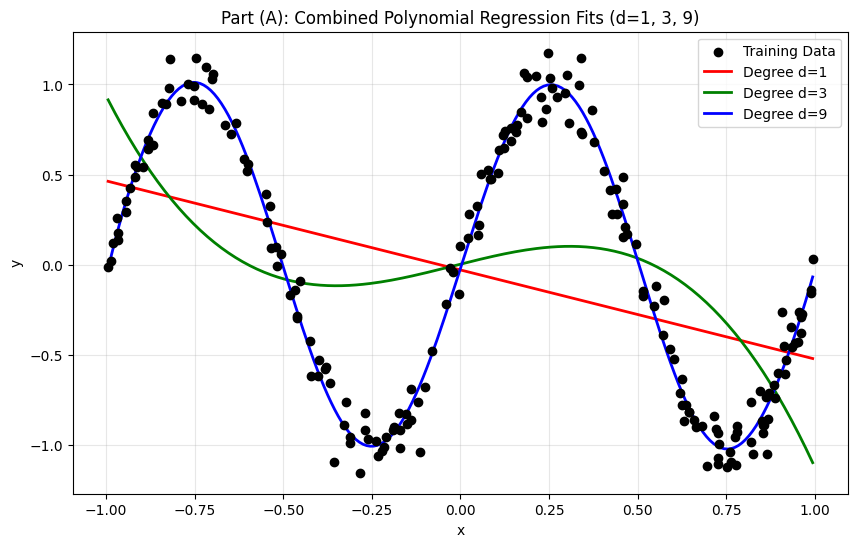

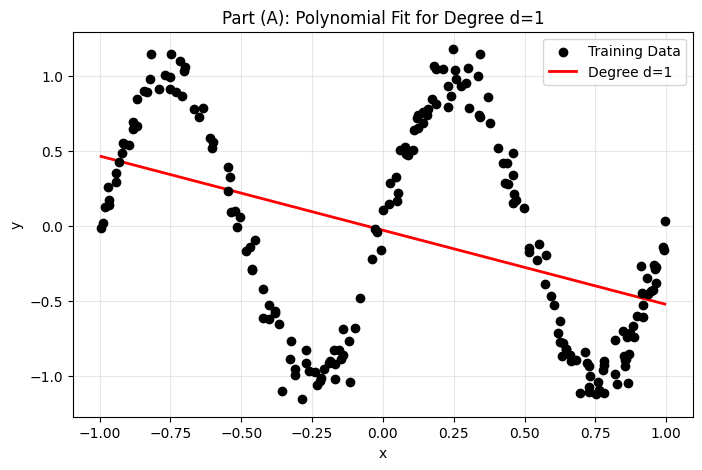

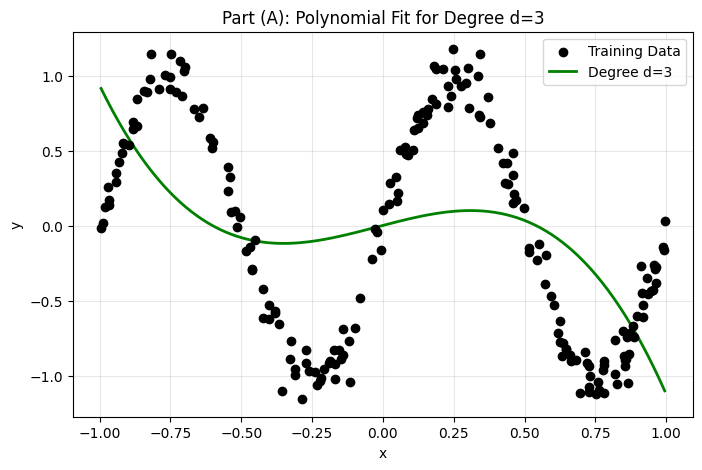

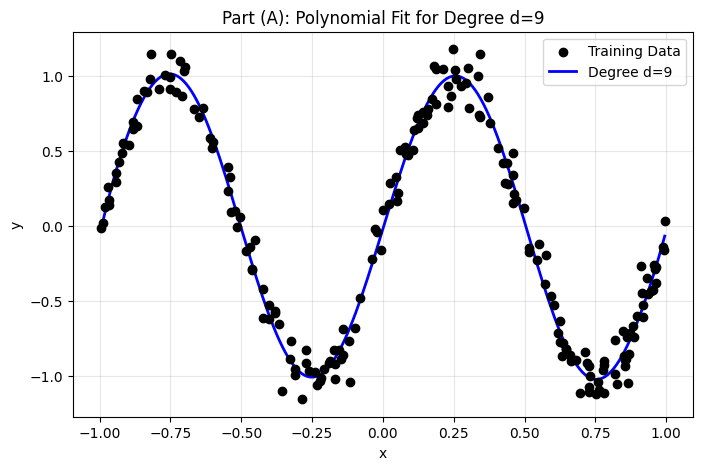

In [3]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

plt.scatter(X_train_A, y_train_A, color='black',
            label='Training Data', zorder=5)

x_min, x_max = X_train_A.min(), X_train_A.max()
x_dense = np.linspace(x_min, x_max, 200)

degrees = [1, 3, 9]
colors = ['red', 'green', 'blue']

for i, d in enumerate(degrees):

    X_poly_train = get_poly_features(X_train_A, d)
    theta = solve_normal_equation(X_poly_train, y_train_A)

    X_poly_dense = get_poly_features(x_dense, d)
    y_dense_pred = X_poly_dense @ theta

    plt.plot(x_dense, y_dense_pred,
             color=colors[i], linewidth=2, label=f'Degree d={d}')

plt.title('Part (A): Combined Polynomial Regression Fits (d=1, 3, 9)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

for i, d in enumerate(degrees):
    plt.figure(figsize=(8, 5))

    plt.scatter(X_train_A, y_train_A, color='black',
                label='Training Data', zorder=5)

    X_poly_train = get_poly_features(X_train_A, d)
    theta = solve_normal_equation(X_poly_train, y_train_A)

    X_poly_dense = get_poly_features(x_dense, d)
    y_dense_pred = X_poly_dense @ theta

    plt.plot(x_dense, y_dense_pred,
             color=colors[i], linewidth=2, label=f'Degree d={d}')

    plt.title(f'Part (A): Polynomial Fit for Degree d={d}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

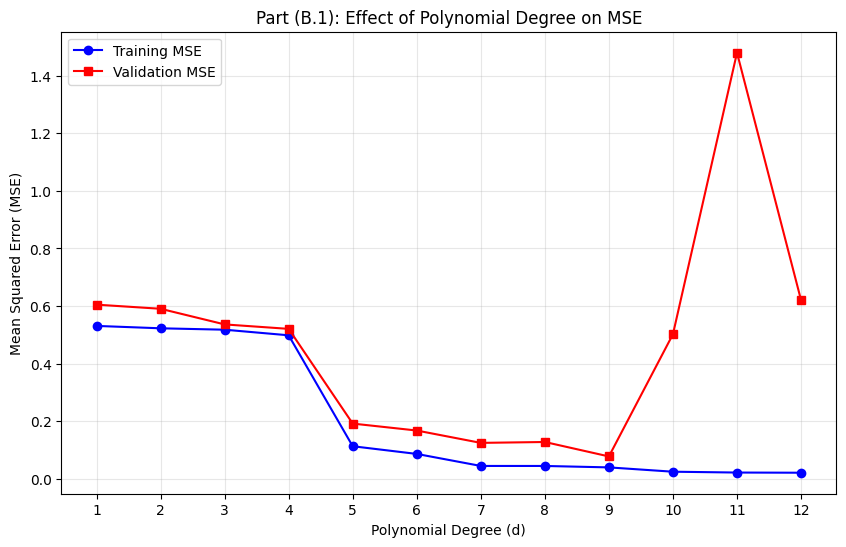

In [4]:
degrees = range(1, 13)
train_mses = []
val_mses = []

for d in degrees:

    X_poly_train = get_poly_features(X_train_B, d)
    X_poly_val = get_poly_features(X_val_B, d)
    theta = solve_normal_equation(X_poly_train, y_train_B)

    y_train_pred = X_poly_train @ theta
    y_val_pred = X_poly_val @ theta

    mse_train = np.mean((y_train_pred - y_train_B)**2)
    mse_val = np.mean((y_val_pred - y_val_B)**2)

    train_mses.append(mse_train)
    val_mses.append(mse_val)

plt.figure(figsize=(10, 6))
plt.plot(degrees, train_mses, 'o-', label='Training MSE', color='blue')
plt.plot(degrees, val_mses, 's-', label='Validation MSE', color='red')
plt.xlabel('Polynomial Degree (d)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Part (B.1): Effect of Polynomial Degree on MSE')
plt.xticks(degrees)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

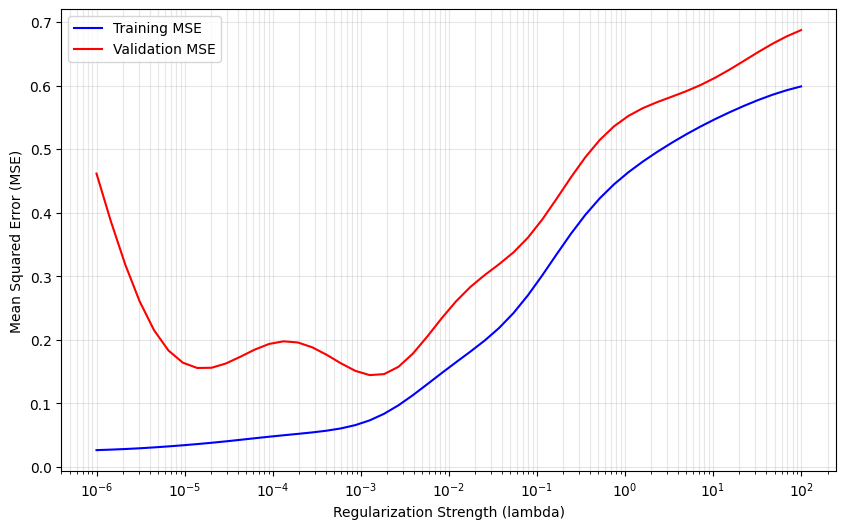

In [5]:
import numpy as np
import matplotlib.pyplot as plt

d_fixed = 12
lambdas = np.logspace(-6, 2, 50)

X_poly_train = get_poly_features(X_train_B, d_fixed)
X_poly_val = get_poly_features(X_val_B, d_fixed)

XTX = X_poly_train.T @ X_poly_train
XTy = X_poly_train.T @ y_train_B
I_matrix = np.eye(XTX.shape[0])

train_mses = []
val_mses = []

for lam in lambdas:

    theta_ridge = np.linalg.inv(XTX + lam * I_matrix) @ XTy

    y_train_pred = X_poly_train @ theta_ridge
    y_val_pred = X_poly_val @ theta_ridge

    mse_train = np.mean((y_train_pred - y_train_B)**2)
    mse_val = np.mean((y_val_pred - y_val_B)**2)

    train_mses.append(mse_train)
    val_mses.append(mse_val)

plt.figure(figsize=(10, 6))
plt.plot(lambdas, train_mses, '-', label='Training MSE', color='blue')
plt.plot(lambdas, val_mses, '-', label='Validation MSE', color='red')

plt.xscale('log')
plt.xlabel('Regularization Strength (lambda)')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True, alpha=0.3, which="both")
plt.show()